# Converting between vector formats

`FeatureCollection.read_file` reads any OGR vector format; `to_file(path)` writes by extension,
and `to_parquet` writes GeoParquet. CRS and attributes carry through.

| Target | Call | Notes |
|--------|------|-------|
| GeoJSON | `to_file('.geojson')` | text, web-friendly |
| Shapefile | `to_file('.shp')` | legacy, multi-file |
| GeoPackage | `to_file('.gpkg')` | single-file SQLite |
| GeoParquet | `to_parquet(...)` | columnar, fast (`[parquet]` extra) |

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-convert-'))  # scratch dir for outputs
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.feature import FeatureCollection

fc = FeatureCollection.read_file(DATA / 'coello_polygons.geojson')
len(fc), fc.epsg

(4, 32618)

Plot the source polygons before converting — every format below stores these same four features.

<Axes: >

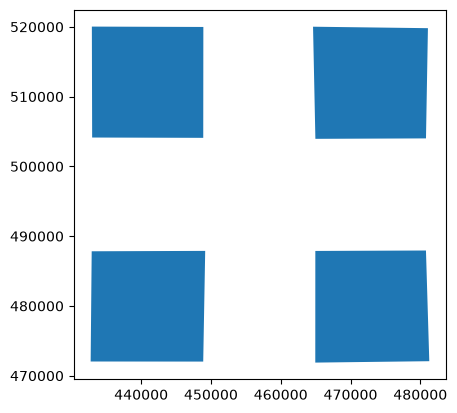

In [3]:
fc.plot()

## GeoJSON → Shapefile and GeoPackage

The extension selects the OGR driver.

In [4]:
shp = WORK / 'polys.shp'
fc.to_file(shp)
gpkg = WORK / 'polys.gpkg'
fc.to_file(gpkg)
(
    len(FeatureCollection.read_file(shp)),
    len(FeatureCollection.read_file(gpkg)),
)

(4, 4)

Read the GeoPackage back and plot it — the geometries and CRS carried through the conversion unchanged.

<Axes: >

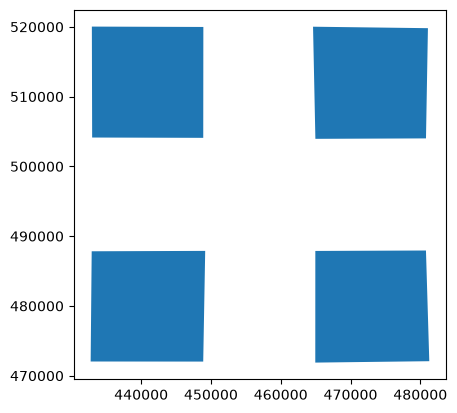

In [5]:
FeatureCollection.read_file(gpkg).plot()

## GeoJSON → GeoParquet

GeoParquet is columnar and compresses well. It needs the `[parquet]` extra
(`pip install 'pyramids-gis[parquet]'`); the cell falls back to a note if it is missing.

In [6]:
pq = WORK / 'polys.parquet'
try:
    fc.to_parquet(pq)
    outcome = ('wrote geoparquet', len(FeatureCollection.read_parquet(pq)))
except Exception as exc:  # pyarrow / parquet extra not installed
    outcome = ('parquet extra missing', type(exc).__name__)
outcome

('wrote geoparquet', 4)

## Notes

- `to_file` infers the OGR driver from the extension; `to_parquet` is the GeoParquet writer.
- Shapefiles truncate field names to 10 chars and split across `.shp/.shx/.dbf/.prj` — prefer
  GeoPackage or GeoParquet for new work.
- See also: [GeoTIFF ↔ NetCDF](geotiff-netcdf.ipynb) and
  [Other raster formats](raster-formats.ipynb).